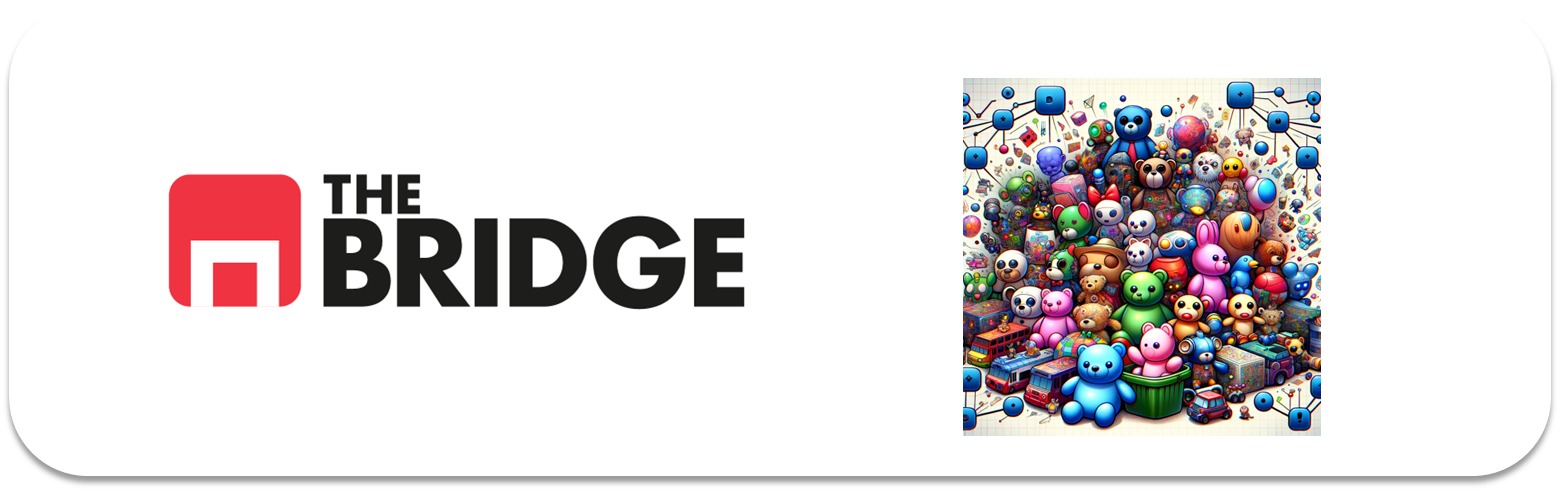

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [21]:
import sklearn
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [9]:
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [10]:
olivetti = fetch_olivetti_faces()

#Mostramos el target
print("Vector Target:")
print(olivetti.target[:50]) 
print("\nForma del target:", olivetti.target.shape)

#Cargamos las características en un DataFrame
df_faces = pd.DataFrame(olivetti.data)

#Añadimos el target al mismo DataFrame
df_faces['target'] = olivetti.target

print("\nDimensiones del DataFrame original con el target:", df_faces.shape)

#Obtenemos otro dataset con las imágenes reordenadas aleatoriamente
#El parámetro 'frac=1' indica que queremos el 100% de las filas mezcladas.
df_faces_shuffled = df_faces.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dimensiones del DataFrame aleatorio:", df_faces_shuffled.shape)

Vector Target:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3
 3 3 3 4 4 4 4 4 4 4 4 4 4]

Forma del target: (400,)

Dimensiones del DataFrame original con el target: (400, 4097)
Dimensiones del DataFrame aleatorio: (400, 4097)


### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [11]:
#Separamos X y el target y del DataFrame
X = df_faces_shuffled.drop(columns=['target'])
y = df_faces_shuffled['target']

#Usamos stratify=y para asegurar que se mantenga la proporción por persona
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

#Dividimos el bloque temporal al 50% para obtener 10% val y 10% test
#Volvemos a usar stratify=y_temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)

# Comprobación de tamaños y equilibrio
print(f"Tamaño del conjunto de Train: {X_train.shape[0]} imagenes")
print(f"Tamaño del conjunto de Val:     {X_val.shape[0]} imagenes")
print(f"Tamaño del conjunto de Test:       {X_test.shape[0]} imagenes\n")

#Comprobamos que haya exactamente el mismo número de imágenes por persona en val
print("Imágenes por persona en Validación (primeras 10 clases):")
print(y_val.value_counts().sort_index().head(10).values)

Tamaño del conjunto de Train: 320 imagenes
Tamaño del conjunto de Val:     40 imagenes
Tamaño del conjunto de Test:       40 imagenes

Imágenes por persona en Validación (primeras 10 clases):
[1 1 1 1 1 1 1 1 1 1]


### #1.4

Crea los pares X,y para train, validation y test.

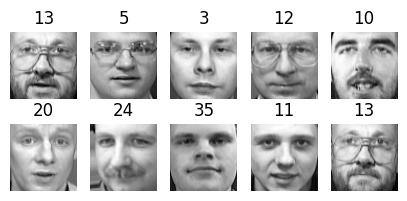

In [15]:
X_train = df_faces_shuffled.drop(columns=['target'])
y_train = df_faces_shuffled['target']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)

#Llamamos a la función plot_faces usando .iloc
#Pasamos los valores usando .values porque la función necesita hacer un .reshape()
plot_faces(X_train.iloc[:10].values, y_train.iloc[:10].values)

Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [14]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [16]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)   
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

In [ ]:
#Definimos el rango de K
k_range = range(5, 151, 5)

best_k = None
best_score = -1
silhouette_scores = []

print("Calculando scores de silueta")

#Evaluamos cada K
for k in k_range:
    #Inicializamos KMeans con un random_state para que sea reproducible
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    #Entrenamos con los datos reducidos por PCA
    labels = kmeans.fit_predict(X_train_pca)
    
    #Calculamos el score de silueta
    score = silhouette_score(X_train_pca, labels)
    silhouette_scores.append(score)
    
    #Guardamos el mejor resultado
    if score > best_score:
        best_score = score
        best_k = k


print("\nBúsqueda completada")
print(f"El mejor número de clústeres (K) es: {best_k}")
print(f"El mejor Score de Silueta obtenido es: {best_score:.4f}")

Calculando scores de silueta

¡Búsqueda completada!
El mejor número de clústeres (K) es: 110
El mejor Score de Silueta obtenido es: 0.2089


### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

Calculando inercias


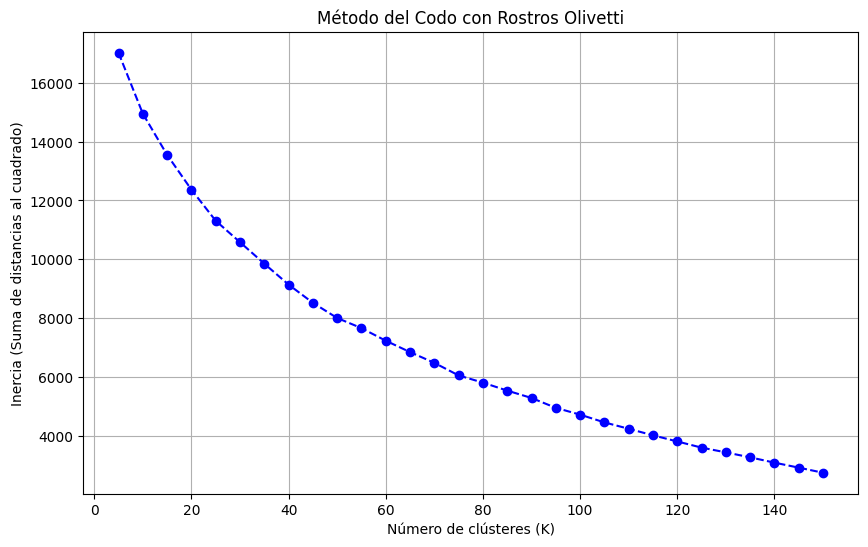

In [18]:
k_range = range(5, 151, 5)
inertias = []

print("Calculando inercias")

#Bucle para calcular la inercia de cada K
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    inertias.append(kmeans.inertia_)

#Dibujamos la gráfica del método del codo de Inercia
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='b')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.title('Método del Codo con Rostros Olivetti')
plt.grid(True)
plt.show()

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [19]:
#Recuperamos el K óptimo obtenido en el paso 1.6
#Usamos directamente best_k que guardó de forma automática el mejor valor
print(f"Inicializando el mejor modelo con K = {best_k}")

#Creamos y entrenamos el modelo definitivo con el K ganador
best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_model.fit(X_train_pca)

print("Modelo 'best_model' entrenado.")

Inicializando el mejor modelo con K = 110
Modelo 'best_model' entrenado.


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?


 MOSTRANDO EL CLÚSTER: 0
 Total de imágenes en este clúster: 3


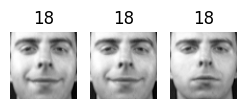


 MOSTRANDO EL CLÚSTER: 1
 Total de imágenes en este clúster: 3


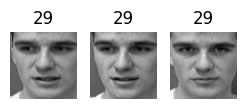


 MOSTRANDO EL CLÚSTER: 2
 Total de imágenes en este clúster: 3


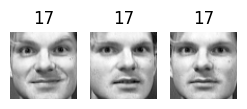


 MOSTRANDO EL CLÚSTER: 3
 Total de imágenes en este clúster: 4


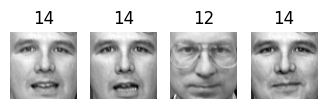


 MOSTRANDO EL CLÚSTER: 4
 Total de imágenes en este clúster: 2


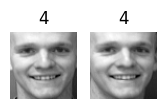


 MOSTRANDO EL CLÚSTER: 5
 Total de imágenes en este clúster: 4


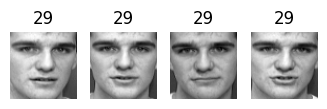


 MOSTRANDO EL CLÚSTER: 6
 Total de imágenes en este clúster: 4


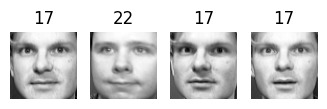


 MOSTRANDO EL CLÚSTER: 7
 Total de imágenes en este clúster: 4


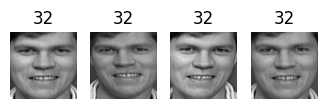


 MOSTRANDO EL CLÚSTER: 8
 Total de imágenes en este clúster: 5


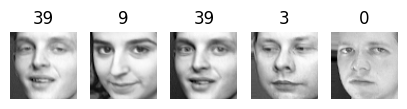


 MOSTRANDO EL CLÚSTER: 9
 Total de imágenes en este clúster: 3


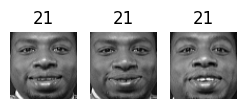

In [20]:
#Obtenemos las etiquetas de los clústeres asignadas a cada imagen de train
cluster_labels = best_model.labels_

#Recorremos los 10 primeros clústeres
for cluster_id in range(10):
    #Buscamos los índices de las imágenes que han caído en el clúster actual
    indices_in_cluster = (cluster_labels == cluster_id)
    
    #Comprobamos si el clúster tiene imágenes asignadas
    if indices_in_cluster.sum() > 0:
        print(f"\n" + "="*40)
        print(f" MOSTRANDO EL CLÚSTER: {cluster_id}")
        print(f" Total de imágenes en este clúster: {indices_in_cluster.sum()}")
        print("="*40)
        
        #FILTRADO CRUCIAL
        # Usamos .iloc con la máscara de booleanos sobre los conjuntos ORIGINALES de píxeles y las etiquetas reales (y_train) para ver a qué persona pertenecen de verdad.
        faces_to_plot = X_train.iloc[indices_in_cluster].values
        true_labels = y_train.iloc[indices_in_cluster].values
        
        plot_faces(faces_to_plot, true_labels)
    else:
        print(f"\nEl clúster {cluster_id} está vacío.")

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [22]:
#Inicializar el clasificador RandomForest con 150 árboles
clf = RandomForestClassifier(n_estimators=150, random_state=42)

clf.fit(X_train_pca, y_train)

#Realizamos las predicciones sobre el conjunto de validación
y_val_pred = clf.predict(X_val_pca)

#Evaluamos el rendimiento del clasificador
accuracy = accuracy_score(y_val, y_val_pred)

print("="*50)
print(f"Precisión (Accuracy) en Validación: {accuracy:.4f} ({accuracy * 100:.1f}%)")
print("="*50)

#Mostramos un reporte detallado 
print("\nReporte de clasificación:")
print("\n".join(classification_report(y_val, y_val_pred).split("\n")[:15]))

Precisión (Accuracy) en Validación: 0.9250 (92.5%)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1


c:\Users\lolar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lolar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lolar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [23]:
#Transformamos todos los datasets utilizando las distancias a los centroides de best_model
X_train_kmeans = best_model.transform(X_train_pca)
X_val_kmeans = best_model.transform(X_val_pca)
X_test_kmeans = best_model.transform(X_test_pca)

#Comprobamos las dimensiones
print(f"Nuevas dimensiones de entrenamiento: {X_train_kmeans.shape}")

#Volvemos a entrenar un RandomForest
clf_kmeans = RandomForestClassifier(n_estimators=150, random_state=42)
clf_kmeans.fit(X_train_kmeans, y_train)

#Evaluamos el rendimiento contra el dataset de validación
y_val_pred_km = clf_kmeans.predict(X_val_kmeans)
accuracy_km = accuracy_score(y_val, y_val_pred_km)

print("="*60)
print(f"Precisión con distancias K-Means en Validación: {accuracy_km:.4f} ({accuracy_km * 100:.1f}%)")
print("="*60)

Nuevas dimensiones de entrenamiento: (320, 110)
Precisión con distancias K-Means en Validación: 0.7750 (77.5%)


### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)

In [24]:
k_options = [20, 40, 60, 80, 100, 120, 140]
best_accuracy = -1
best_k_for_rf = None

for k in k_options:
    #a-Creamos un KMeans temporal con 'k' clústeres y entrenarlo
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    X_train_temp = kmeans_temp.fit_transform(X_train_pca)
    X_val_temp = kmeans_temp.transform(X_val_pca)
    
    #b-Entrenamos el RandomForest con estas nuevas características de distancia
    rf_temp = RandomForestClassifier(n_estimators=150, random_state=42)
    rf_temp.fit(X_train_temp, y_train)
    
    #c-Medimos rendimiento en Validación
    acc = accuracy_score(y_val, rf_temp.predict(X_val_temp))
    print(f"Probando K={k} -> Accuracy en Validación: {acc:.4f}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_k_for_rf = k

print(f"\nEl mejor K es {best_k_for_rf} con un Accuracy de {best_accuracy:.4f}")

Probando K=20 -> Accuracy en Validación: 0.6750
Probando K=40 -> Accuracy en Validación: 0.8250
Probando K=60 -> Accuracy en Validación: 0.7500
Probando K=80 -> Accuracy en Validación: 0.7750
Probando K=100 -> Accuracy en Validación: 0.7500
Probando K=120 -> Accuracy en Validación: 0.7250
Probando K=140 -> Accuracy en Validación: 0.7750

El mejor K es 40 con un Accuracy de 0.8250
